# Online Shoppers Intention Analysis

数据集信息：**Online Shoppers Purchasing Intention Dataset**，来源于 UCI Machine Learning Repository。约 12,330 条用户浏览会话记录，18 个特征（数值型 + 类别型），目标变量 `Revenue`（是否产生购买，True/False）。

In [18]:
# 统一导入所有依赖
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, silhouette_score)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

## Part 1: 数据加载与探索性分析

In [19]:
# 基础显示设置
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.unicode_minus"] = False

# 启用常见中文字体
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]

### a. 数据加载与基础检查
读取数据后查看数据规模、样例、字段类型、统计摘要与缺失值情况。

In [20]:
data_path = "data/online_shoppers_intention.csv"
df = pd.read_csv(data_path)

print(f"数据形状: {df.shape}")
display(df.head())

print("\nDataFrame.info():")
df.info()

print("\n数值统计摘要 (describe):")
display(df.describe())

print("\n包含类别变量在内的统计摘要 (describe include='all'):")
display(df.describe(include="all"))

数据形状: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False



DataFrame.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  Tra

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000



包含类别变量在内的统计摘要 (describe include='all'):


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330,12330
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,NaN,3,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,May,NaN,NaN,NaN,NaN,Returning_Visitor,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3364,NaN,NaN,NaN,NaN,10551,9462,10422
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,NaN,2.124006,2.357097,3.147364,4.069586,NaN,NaN,NaN
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,NaN,0.911325,1.717277,2.401591,4.025169,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,NaN,2.000000,2.000000,1.000000,2.000000,NaN,NaN,NaN
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,NaN,2.000000,2.000000,3.000000,2.000000,NaN,NaN,NaN
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,NaN,3.000000,2.000000,4.000000,4.000000,NaN,NaN,NaN


In [21]:
# 缺失值统计（数量 + 占比）
missing_count = df.isnull().sum()
missing_ratio = (missing_count / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_ratio_percent": missing_ratio
}).sort_values("missing_ratio_percent", ascending=False)

display(missing_summary)

if missing_summary["missing_count"].sum() == 0:
    print("未发现缺失值。")
else:
    print("存在缺失值，请在后续预处理中处理。")

,missing_count,missing_ratio_percent
Administrative,0,0.0
Administrative_Duration,0,0.0
Informational,0,0.0
Informational_Duration,0,0.0
ProductRelated,0,0.0
ProductRelated_Duration,0,0.0
BounceRates,0,0.0
ExitRates,0,0.0
PageValues,0,0.0
SpecialDay,0,0.0


未发现缺失值。


### b. 目标变量分布分析
统计 `Revenue` 的类别数量与占比

Revenue 类别计数:


,count
Revenue,
False,10422
True,1908


Revenue 类别占比(%):


,ratio_percent
Revenue,
False,84.53
True,15.47


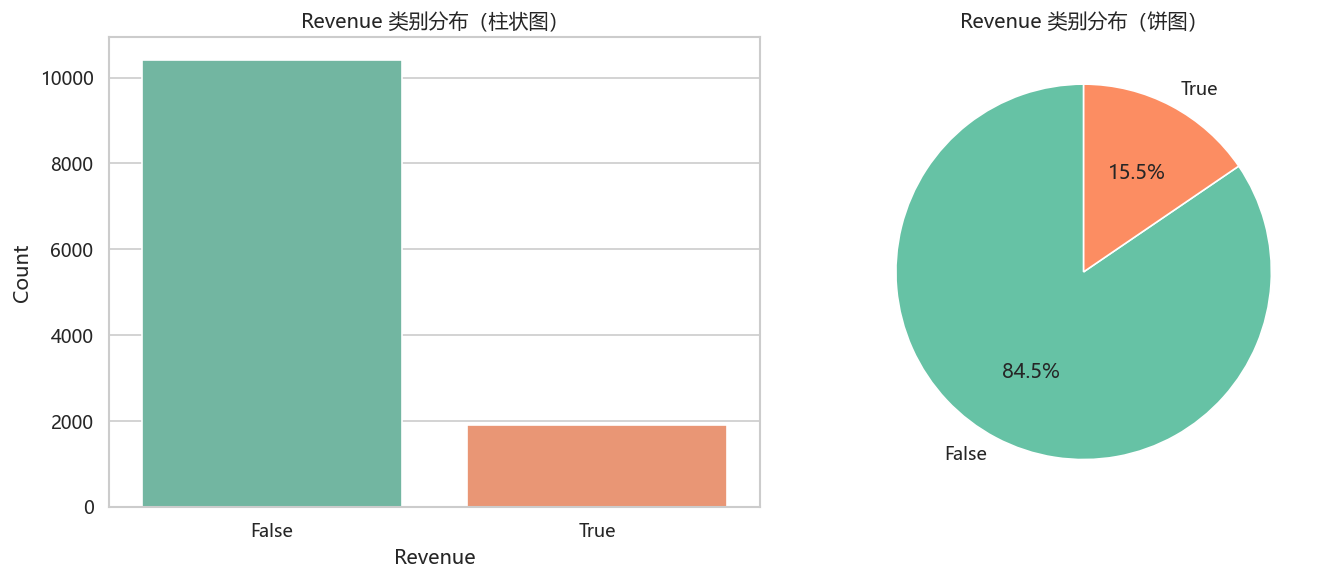

In [22]:
if "Revenue" not in df.columns:
    raise KeyError("未找到目标变量列 'Revenue'。")

revenue_counts = df["Revenue"].value_counts(dropna=False)
revenue_ratio = df["Revenue"].value_counts(normalize=True, dropna=False).mul(100).round(2)

print("Revenue 类别计数:")
display(revenue_counts.to_frame(name="count"))

print("Revenue 类别占比(%):")
display(revenue_ratio.to_frame(name="ratio_percent"))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x="Revenue", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Revenue 类别分布（柱状图）")
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("Count")

axes[1].pie(
    revenue_counts.values,
    labels=revenue_counts.index.astype(str),
    autopct="%.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2", n_colors=len(revenue_counts))
)
axes[1].set_title("Revenue 类别分布（饼图）")

plt.tight_layout()
plt.show()

### c. 数值特征分布可视化
绘制数值特征的直方图与箱线图，观察分布形态与异常值

数值特征数量: 14
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']


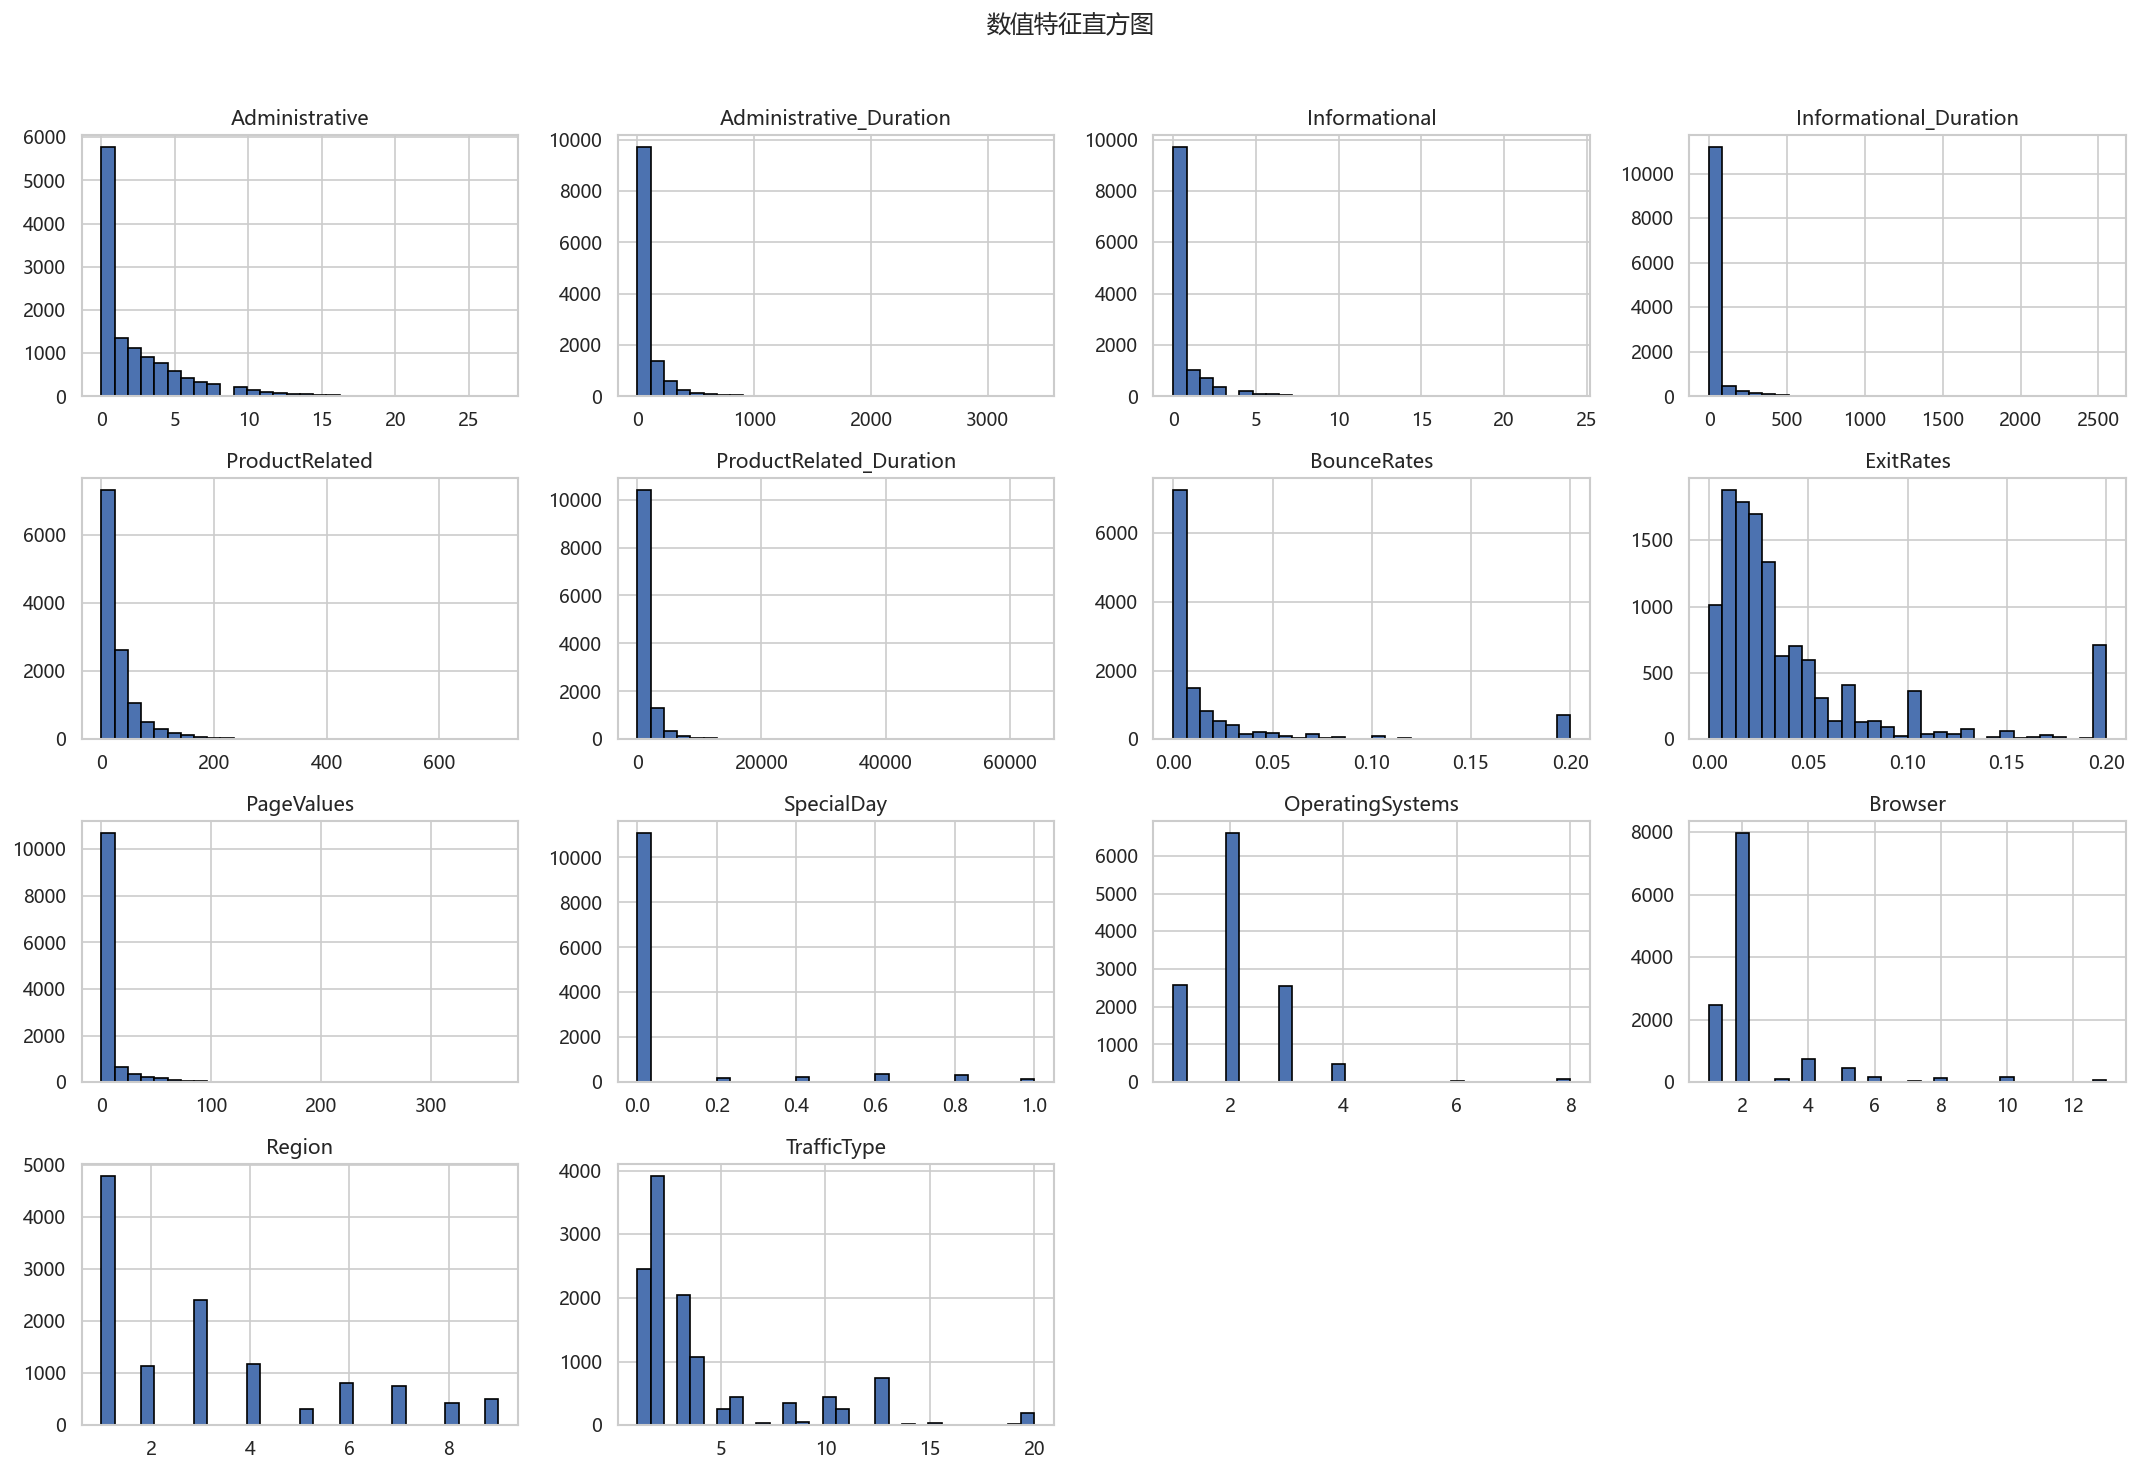

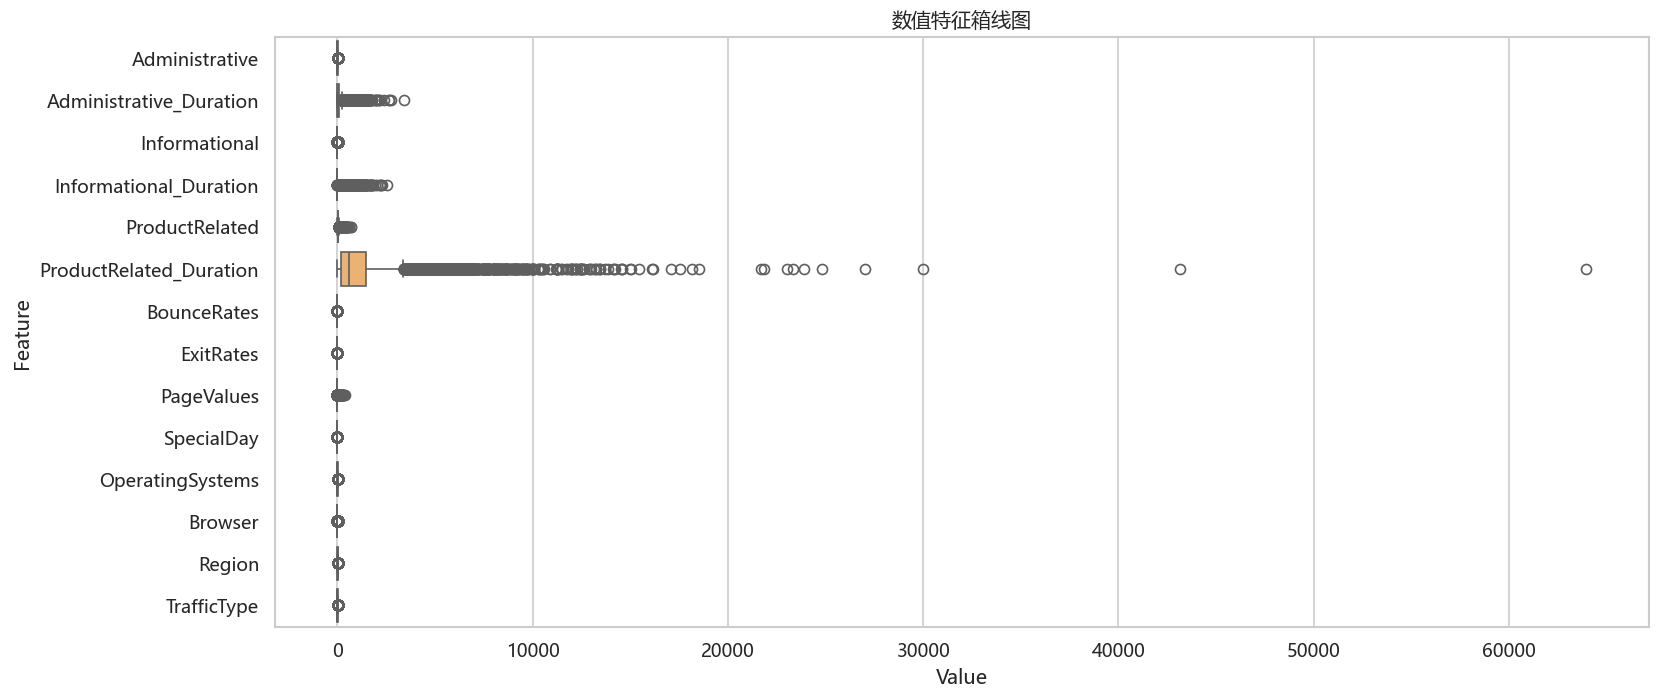

In [23]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"数值特征数量: {len(num_cols)}")
print(num_cols)

# 直方图
_ = df[num_cols].hist(bins=30, figsize=(18, 12), edgecolor="black")
plt.suptitle("数值特征直方图", y=1.02)
plt.tight_layout()
plt.show()

# 箱线图
plt.figure(figsize=(14, max(6, len(num_cols) * 0.35)))
sns.boxplot(data=df[num_cols], orient="h", palette="Set3")
plt.title("数值特征箱线图")
plt.xlabel("Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### d. 类别特征频率统计
统计 `Month`、`VisitorType`、`Weekend` 的频数与占比


=== Month 频数统计 ===


,count,ratio_percent
Month,,
May,3364,27.28
Nov,2998,24.31
Mar,1907,15.47
Dec,1727,14.01
Oct,549,4.45
Sep,448,3.63
Aug,433,3.51
Jul,432,3.50
June,288,2.34



=== VisitorType 频数统计 ===


,count,ratio_percent
VisitorType,,
Returning_Visitor,10551,85.57
New_Visitor,1694,13.74
Other,85,0.69



=== Weekend 频数统计 ===


,count,ratio_percent
Weekend,,
False,9462,76.74
True,2868,23.26


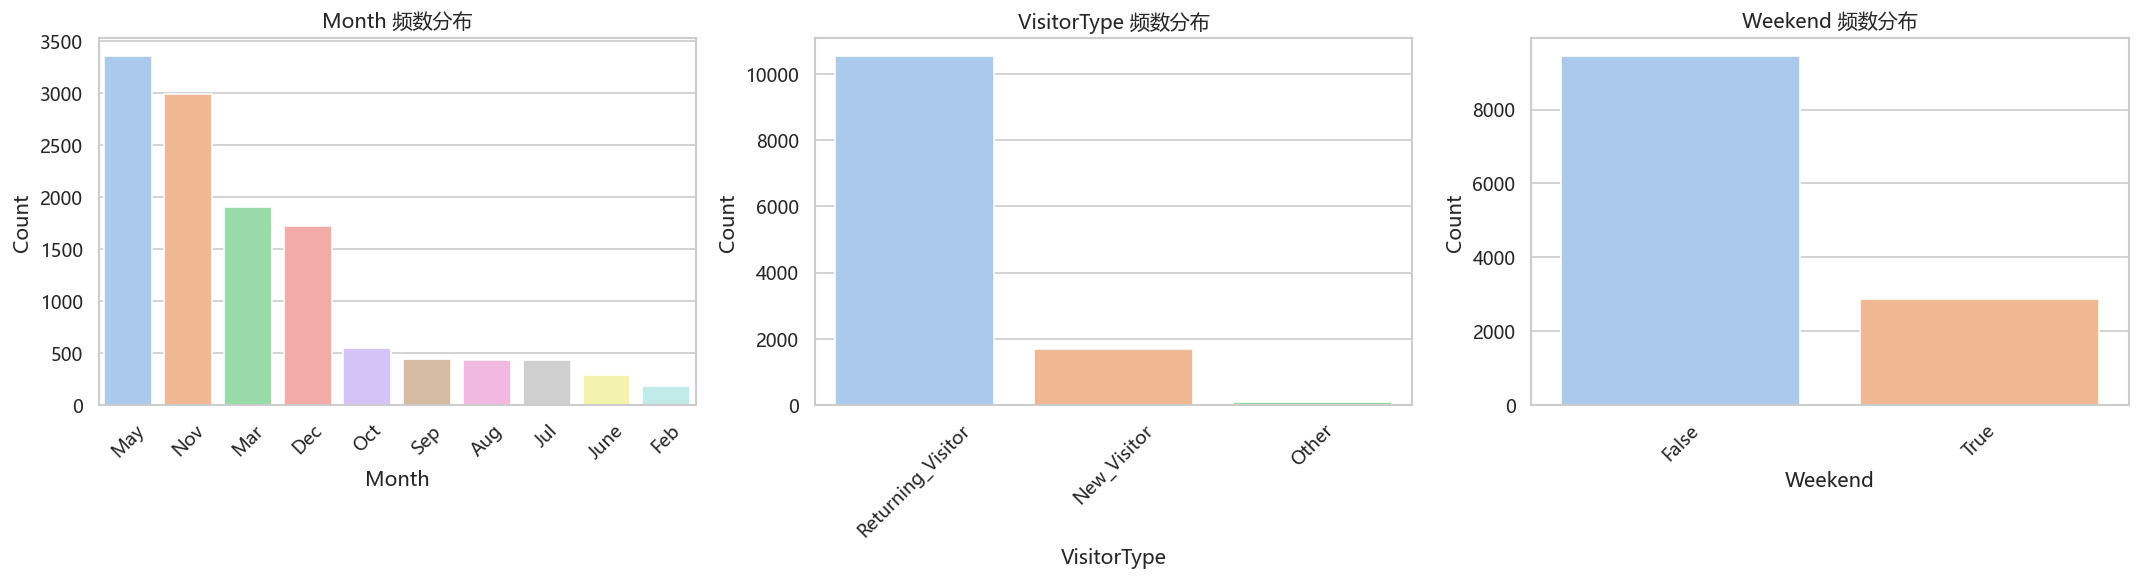

In [24]:
cat_cols = ["Month", "VisitorType", "Weekend"]
existing_cat_cols = [c for c in cat_cols if c in df.columns]
missing_cat_cols = [c for c in cat_cols if c not in df.columns]

if missing_cat_cols:
    print(f"以下类别列不存在，将跳过: {missing_cat_cols}")

for col in existing_cat_cols:
    print(f"\n=== {col} 频数统计 ===")
    counts = df[col].value_counts(dropna=False)
    ratio = df[col].value_counts(normalize=True, dropna=False).mul(100).round(2)
    summary = pd.DataFrame({"count": counts, "ratio_percent": ratio})
    display(summary)

if existing_cat_cols:
    n = len(existing_cat_cols)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, existing_cat_cols):
        order = df[col].value_counts(dropna=False).index
        sns.countplot(data=df, x=col, order=order, ax=ax, palette="pastel")
        ax.set_title(f"{col} 频数分布")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

### e. 相关性热力图
计算数值特征的相关系数矩阵并绘制热力图

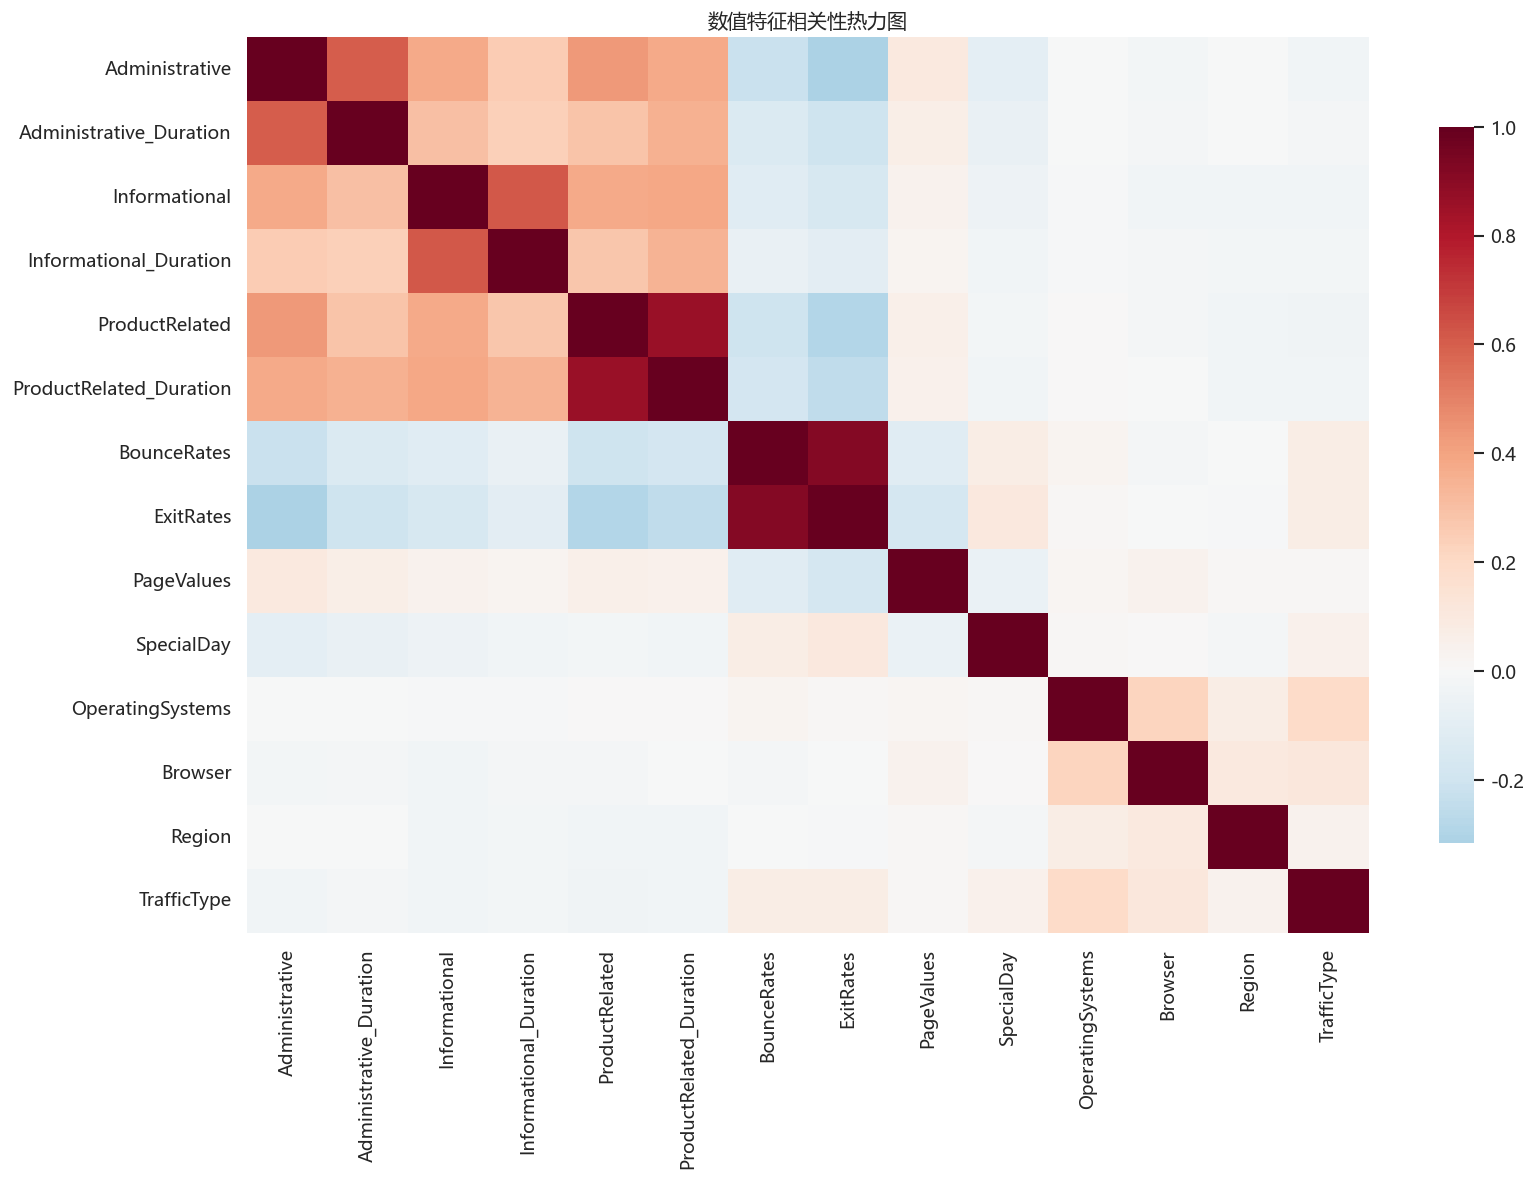

In [25]:
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    cmap="RdBu_r",
    center=0,
    square=False,
    cbar_kws={"shrink": 0.8}
)
plt.title("数值特征相关性热力图")
plt.tight_layout()
plt.show()

## Part 2: 数据预处理

### a. 类别特征编码
使用 `pd.get_dummies` 对指定类别列进行独热编码，使用 `drop_first=True` 丢弃每组的第一个哑变量，避免完全多重共线性（虚拟变量陷阱）。

In [26]:
# 目标变量与特征拆分
y = df["Revenue"].astype(int)
X = df.drop(columns=["Revenue"]).copy()

# 类别特征编码
cat_cols_to_encode = [
    "Month", "VisitorType", "Weekend",
    "OperatingSystems", "Browser", "Region", "TrafficType"
]
existing_cat_cols = [c for c in cat_cols_to_encode if c in X.columns]
missing_cat_cols = [c for c in cat_cols_to_encode if c not in X.columns]

if missing_cat_cols:
    print(f"以下指定类别列不存在，将自动跳过: {missing_cat_cols}")

for col in existing_cat_cols:
    X[col] = X[col].astype(str)

X_encoded = pd.get_dummies(X, columns=existing_cat_cols, drop_first=True)
print(f"编码后特征维度: {X_encoded.shape}")
display(X_encoded.head())

编码后特征维度: (12330, 68)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_19,TrafficType_2,TrafficType_20,TrafficType_3,TrafficType_4,TrafficType_5,TrafficType_6,TrafficType_7,TrafficType_8,TrafficType_9
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,False,True,False,False,False,False,False,False,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,True,False,False,False,False,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,False,False,False,False,True,False,False,False,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,False,False,False,False,True,False,False,False,False,False


### b. 训练集/测试集划分
按照 80/20 划分数据集，并使用 `stratify=y` 保持目标变量类别比例一致。

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train 形状: {X_train.shape}, X_test 形状: {X_test.shape}")
print("\n原始训练集类别分布:")
display(y_train.value_counts().sort_index().to_frame(name="count"))

X_train 形状: (9864, 68), X_test 形状: (2466, 68)

原始训练集类别分布:


,count
Revenue,
0,8338
1,1526


### c. 特征标准化
使用 `StandardScaler` 对特征做标准化，分别准备监督学习（SVM）与聚类（K-Means）使用的数据。

In [28]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# 为 K-Means 额外准备全量标准化特征
cluster_scaler = StandardScaler()
X_cluster_scaled = pd.DataFrame(
    cluster_scaler.fit_transform(X_encoded),
    columns=X_encoded.columns,
    index=X_encoded.index
)

print("标准化完成：")
print(f"X_train_scaled 形状: {X_train_scaled.shape}")
print(f"X_test_scaled 形状: {X_test_scaled.shape}")
print(f"X_cluster_scaled 形状: {X_cluster_scaled.shape}")

标准化完成：
X_train_scaled 形状: (9864, 68)
X_test_scaled 形状: (2466, 68)
X_cluster_scaled 形状: (12330, 68)


### d. 处理类别不平衡
优先使用 `SMOTE` 对训练集做过采样，同时保留 `class_weight='balanced'` 作为分类模型的备选方案。

In [29]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("SMOTE 后训练集类别分布:")
display(pd.Series(y_train_smote).value_counts().sort_index().to_frame(name="count"))

class_weight_option = "balanced"
print(f"分类模型可选类权重参数: class_weight='{class_weight_option}'")

SMOTE 后训练集类别分布:


,count
Revenue,
0,8338
1,8338


分类模型可选类权重参数: class_weight='balanced'


## Part 3: 无监督学习：K-Means 聚类
围绕 K 值选择、聚类可视化、簇画像解释，并尝试将聚类标签作为监督学习的新特征。

### a. 用肘部法则与轮廓系数评估 K 值

K 值评估抽样样本量: 5000
肘部法则数据（SSE）：


,k,SSE
0,2,322592.410641
1,3,313510.608921
2,4,303215.193043
3,5,290657.970186
4,6,287053.135359



轮廓系数数据：


,k,silhouette_score
0,2,0.086130
1,3,0.083807
2,4,0.032261
3,5,0.061780
4,6,0.058841



全局最高轮廓系数对应 K: 2
在 K=3 与 K=4 中，最终选择 K: 3


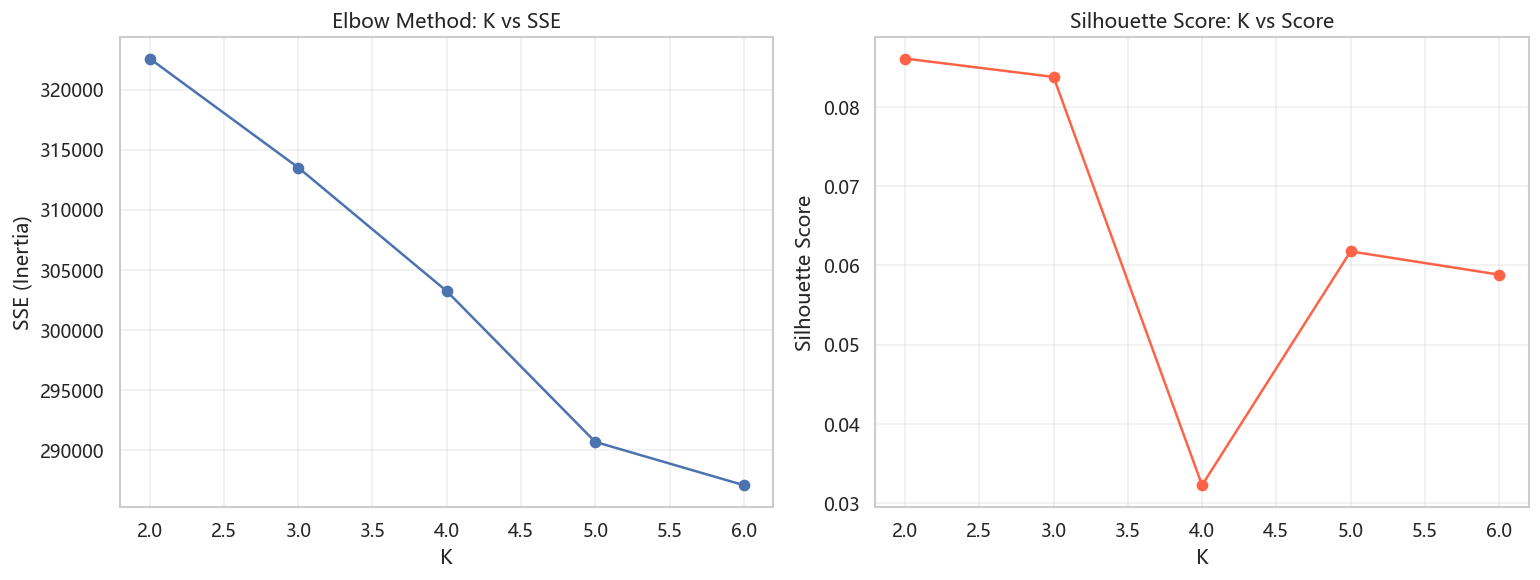

In [30]:
k_values = [2, 3, 4, 5, 6]

# 为了提高运行速度，在样本上估计 K 的趋势
k_eval_size = min(5000, len(X_cluster_scaled))
X_k_eval = X_cluster_scaled.sample(n=k_eval_size, random_state=42)

sse_scores = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_k = km.fit_predict(X_k_eval)
    sse_scores.append(km.inertia_)
    sil_scores.append(silhouette_score(X_k_eval, labels_k))

elbow_df = pd.DataFrame({"k": k_values, "SSE": sse_scores})
sil_df = pd.DataFrame({"k": k_values, "silhouette_score": sil_scores})

sil_3 = sil_df.loc[sil_df["k"] == 3, "silhouette_score"].iloc[0]
sil_4 = sil_df.loc[sil_df["k"] == 4, "silhouette_score"].iloc[0]
best_k_sil = sil_df.loc[sil_df["silhouette_score"].idxmax(), "k"]

# 按题目要求在 K=3 或 K=4 中选择更优者
selected_k = 3 if sil_3 >= sil_4 else 4

print(f"K 值评估抽样样本量: {k_eval_size}")
print("肘部法则数据（SSE）：")
display(elbow_df)
print("\n轮廓系数数据：")
display(sil_df)
print(f"\n全局最高轮廓系数对应 K: {best_k_sil}")
print(f"在 K=3 与 K=4 中，最终选择 K: {selected_k}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(elbow_df["k"], elbow_df["SSE"], marker="o")
axes[0].set_title("Elbow Method: K vs SSE")
axes[0].set_xlabel("K")
axes[0].set_ylabel("SSE (Inertia)")
axes[0].grid(alpha=0.3)

axes[1].plot(sil_df["k"], sil_df["silhouette_score"], marker="o", color="tomato")
axes[1].set_title("Silhouette Score: K vs Score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### b. 使用选定的 K 进行聚类，并用 PCA 降维到 2D 可视化

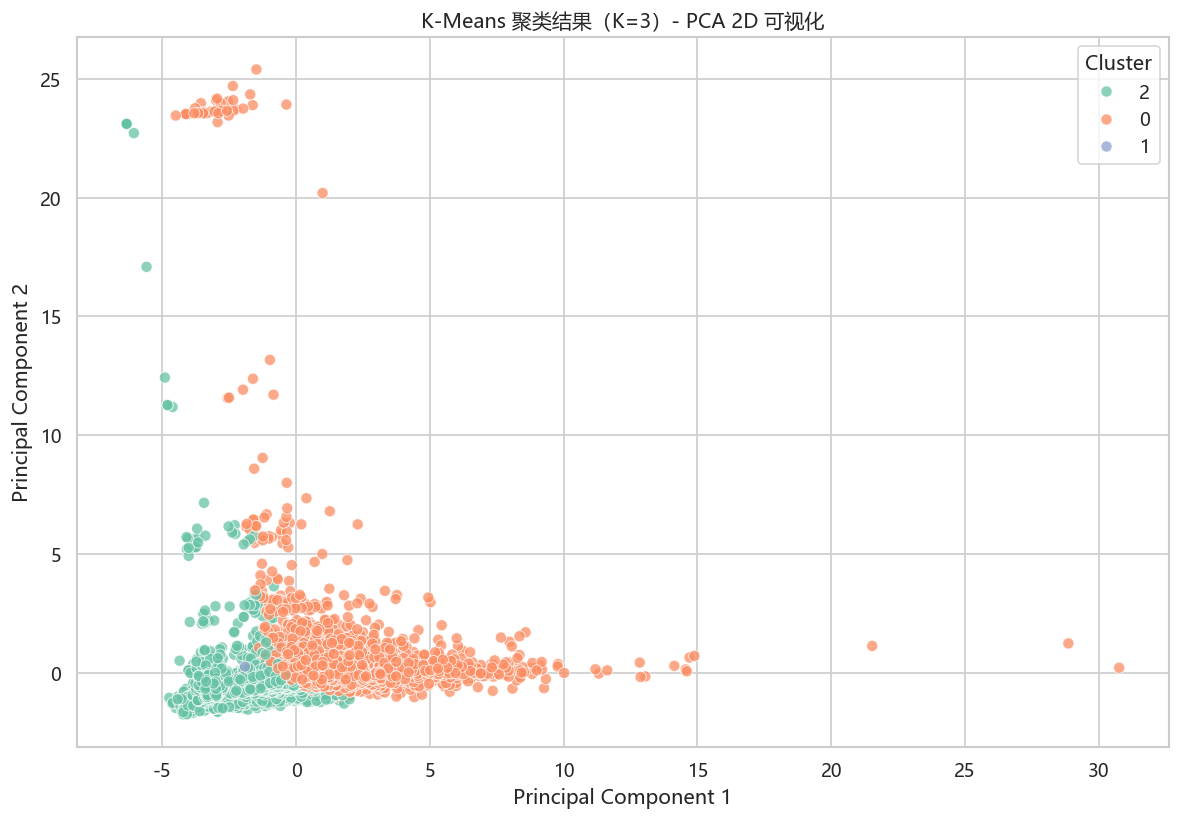

PCA 前两主成分累计解释方差比: 9.92%

各簇样本量：


,count
Cluster,
0,6647
1,6
2,5677


In [ ]:
kmeans_final = KMeans(n_clusters=selected_k, random_state=42, n_init=20)
cluster_labels = pd.Series(
    kmeans_final.fit_predict(X_cluster_scaled),
    index=X_cluster_scaled.index,
    name="Cluster"
 )

# 保留一个带簇标签的数据副本，避免污染原始输入
profile_df = df.copy()
profile_df["Cluster"] = cluster_labels

pca = PCA(n_components=2, random_state=42)
X_pca_2d = pca.fit_transform(X_cluster_scaled)
explained = pca.explained_variance_ratio_.sum()

plot_df = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"], index=X_cluster_scaled.index)
plot_df["Cluster"] = cluster_labels.astype(str)
plot_df["Revenue"] = y.astype(int).map({0: "No", 1: "Yes"})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    alpha=0.75,
    s=45
 )
plt.title(f"K-Means 聚类结果（K={selected_k}）- PCA 2D 可视化")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

print(f"PCA 前两主成分累计解释方差比: {explained:.2%}")
print("\n各簇样本量：")
cluster_size = profile_df["Cluster"].value_counts().sort_index().to_frame(name="count")
display(cluster_size)

### c. 簇画像分析：比较关键特征均值，识别高意向/浏览型/跳出型用户

In [ ]:
key_features = [
    "PageValues", "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "Administrative_Duration",
    "Informational_Duration", "Revenue"
]
key_features = [c for c in key_features if c in profile_df.columns]

cluster_profile = profile_df.groupby("Cluster")[key_features].mean().round(4)
print("各簇关键特征均值：")
display(cluster_profile)

cluster_ids = cluster_profile.index.tolist()
remaining = cluster_ids.copy()

# 高意向：Revenue 均值最高
high_intent_cluster = cluster_profile["Revenue"].idxmax()
remaining.remove(high_intent_cluster)

# 跳出型：在剩余簇中 BounceRates 均值最高
if remaining:
    bounce_cluster = cluster_profile.loc[remaining, "BounceRates"].idxmax()
    remaining.remove(bounce_cluster)
else:
    bounce_cluster = high_intent_cluster

name_map = {high_intent_cluster: "高意向用户"}
if bounce_cluster not in name_map:
    name_map[bounce_cluster] = "跳出型用户"

if remaining:
    name_map[remaining[0]] = "浏览型用户"
for extra_c in remaining[1:]:
    name_map[extra_c] = "混合探索用户"

summary_rows = []
for cid in cluster_ids:
    row = {
        "Cluster": cid,
        "用户类型": name_map.get(cid, "其他"),
        "样本数": int((profile_df["Cluster"] == cid).sum()),
        "Revenue均值": float(cluster_profile.loc[cid, "Revenue"])
    }
    if "PageValues" in cluster_profile.columns:
        row["PageValues均值"] = float(cluster_profile.loc[cid, "PageValues"])
    if "BounceRates" in cluster_profile.columns:
        row["BounceRates均值"] = float(cluster_profile.loc[cid, "BounceRates"])
    if "ExitRates" in cluster_profile.columns:
        row["ExitRates均值"] = float(cluster_profile.loc[cid, "ExitRates"])
    summary_rows.append(row)

cluster_interpretation = pd.DataFrame(summary_rows).sort_values("Cluster").reset_index(drop=True)
print("\n簇画像解释：")
display(cluster_interpretation)

各簇关键特征均值：


,PageValues,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,Administrative_Duration,Informational_Duration,Revenue
Cluster,,,,,,,,
0,9.4078,44.9559,1730.1642,0.0050,0.0214,130.2873,60.1504,0.2401
1,4.3648,12.1667,822.4055,0.0131,0.0439,24.5556,2.1667,0.1667
2,1.7711,16.2681,568.2377,0.0423,0.0685,22.9570,4.4411,0.0548



簇画像解释：


,Cluster,用户类型,样本数,Revenue均值,PageValues均值,BounceRates均值,ExitRates均值
0,0,高意向用户,6647,0.2401,9.4078,0.0050,0.0214
1,1,浏览型用户,6,0.1667,4.3648,0.0131,0.0439
2,2,跳出型用户,5677,0.0548,1.7711,0.0423,0.0685


### d. 将聚类标签作为新特征加入分类模型

In [ ]:
X_with_cluster = X_encoded.copy()
X_with_cluster["Cluster"] = cluster_labels.astype(int)

# 使用与基线模型相同的样本划分索引，保证可比性
Xc_train = X_with_cluster.loc[X_train.index]
Xc_test = X_with_cluster.loc[X_test.index]
yc_train = y.loc[X_train.index]
yc_test = y.loc[X_test.index]

rf_base = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight=class_weight_option,
    n_jobs=-1
)
rf_plus = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight=class_weight_option,
    n_jobs=-1
)

base_cv = cross_val_score(rf_base, X_train, y_train, cv=5, scoring="accuracy")
plus_cv = cross_val_score(rf_plus, Xc_train, yc_train, cv=5, scoring="accuracy")

rf_base.fit(X_train, y_train)
rf_plus.fit(Xc_train, yc_train)
base_test_acc = rf_base.score(X_test, y_test)
plus_test_acc = rf_plus.score(Xc_test, yc_test)

print("随机森林（是否加入 Cluster 特征）对比：")
comparison_df = pd.DataFrame({
    "方案": ["Baseline（无聚类特征）", "Plus（加入聚类特征）"],
    "CV-Accuracy(mean)": [base_cv.mean(), plus_cv.mean()],
    "CV-Accuracy(std)": [base_cv.std(), plus_cv.std()],
    "Test-Accuracy": [base_test_acc, plus_test_acc]
})
display(comparison_df)

if plus_test_acc >= base_test_acc:
    print("加入聚类特征后，测试集准确率提升或持平。")
else:
    print("加入聚类特征后，测试集准确率略有下降，可进一步调参与特征工程。")

随机森林（是否加入 Cluster 特征）对比：


,方案,CV-Accuracy(mean),CV-Accuracy(std),Test-Accuracy
0,Baseline（无聚类特征）,0.902068,0.004137,0.897405
1,Plus（加入聚类特征）,0.902474,0.003882,0.898621


加入聚类特征后，测试集准确率提升或持平。
